# Scenario 4 – Stacking
**Roll Number:** 24BAD002  
**Name:** Abhishek J

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print(f"Roll Number: 24BAD002")
print(f"Name: Abhishek J")


Roll Number: 24BAD002
Name: Abhishek J


## 1. Load Dataset

In [2]:
df = pd.read_csv("heart_stacking.csv")
print("Shape:", df.shape)
print(df.head())
print("\nClass Distribution:")
print(df['HeartDisease'].value_counts())


Shape: (120, 5)
   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0

Class Distribution:
HeartDisease
1    83
0    37
Name: count, dtype: int64


## 2. Prepare Features

In [3]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Train: 96, Test: 24


## 3. Train Base Models Individually

In [4]:
results = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
results['Logistic Regression'] = accuracy_score(y_test, lr.predict(X_test_sc))

# SVM
svm = SVC(probability=True, kernel='rbf', random_state=42)
svm.fit(X_train_sc, y_train)
results['SVM'] = accuracy_score(y_test, svm.predict(X_test_sc))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
results['Decision Tree'] = accuracy_score(y_test, dt.predict(X_test))

for name, acc in results.items():
    print(f"{name}: {acc:.4f}")


Logistic Regression: 0.7917
SVM: 0.9583
Decision Tree: 1.0000


## 4. Apply StackingClassifier

In [5]:
base_learners = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
]
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

stack = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    passthrough=False,
    cv=5
)
stack.fit(X_train_sc, y_train)
stack_acc = accuracy_score(y_test, stack.predict(X_test_sc))
results['Stacking'] = stack_acc
print(f"Stacking Accuracy: {stack_acc:.4f}")


Stacking Accuracy: 1.0000


## 5. Visualization – Model Comparison Bar Chart

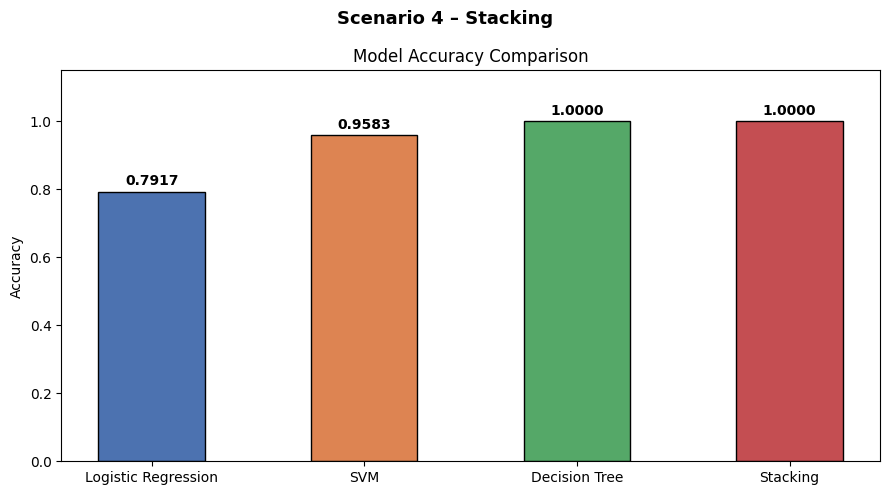

Plot saved.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(f"Scenario 4 – Stacking", fontsize=13, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='black', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
for bar, acc in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{acc:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("scenario4_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


## Summary

In [8]:
best_base = max({k: v for k, v in results.items() if k != 'Stacking'}, key=results.get)

for name, acc in results.items():
    print(f"  {name:<22}: {acc:.4f}")
print(f"  Stacking vs Best Base: {stack_acc - results[best_base]:+.4f}")



  Logistic Regression   : 0.7917
  SVM                   : 0.9583
  Decision Tree         : 1.0000
  Stacking              : 1.0000
  Stacking vs Best Base: +0.0000
